# Optimal Portfolio Allocation Using Historical Stock Data

Goal

Find the portfolio weights that:
- maximize expected return for a given risk level
OR
- minimize risk for a target return

subject to constraints like:
- weights sum to 1
- no short selling (weight >= 0)
- optional max allocation per asset

### Import required packages and download financial data

In [66]:
import yfinance as yf
import pandas as pd
import datetime as dt
import numpy as np

# Define the stock tickers and the date range for historical data
tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN']
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*3)

data = yf.download(tickers, start=startDate, end=endDate, auto_adjust=True)['Close']
print(data.head())

[*********************100%***********************]  4 of 4 completed

Ticker            AAPL        AMZN        MSFT       NVDA
Date                                                     
2023-05-16  169.691071  113.400002  304.528137  29.187162
2023-05-17  170.302475  115.500000  307.406494  30.151306
2023-05-18  172.629868  118.150002  311.831543  31.649981
2023-05-19  172.738342  116.250000  311.655334  31.236345
2023-05-22  171.791611  115.010002  314.435608  31.148426


### Compute Daily Returns

In [67]:
# Calculate daily returns with percentage change and drop the first row which will be NaN
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,AMZN,MSFT,NVDA
Date,,,,
2023-05-17,0.003603,0.018519,0.009452,0.033033
2023-05-18,0.013666,0.022944,0.014395,0.049705
2023-05-19,0.000628,-0.016081,-0.000565,-0.013069
2023-05-22,-0.005481,-0.010667,0.008921,-0.002815
2023-05-23,-0.015155,-0.000174,-0.018432,-0.015653


### Compute Expected Returns and Covariance Matrix

In [68]:
# Expected annual returns
mean_returns = returns.mean() * 252

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

mean_returns, cov_matrix

(Ticker
 AAPL    0.226844
 AMZN    0.329311
 MSFT    0.139463
 NVDA    0.808209
 dtype: float64,
 Ticker      AAPL      AMZN      MSFT      NVDA
 Ticker                                        
 AAPL    0.066616  0.034787  0.025642  0.044063
 AMZN    0.034787  0.096292  0.039680  0.069039
 MSFT    0.025642  0.039680  0.055885  0.058502
 NVDA    0.044063  0.069039  0.058502  0.239689)

### Define Portfolio Functions

**Portfolio return**. Calculates the expected return of a portfolio.

$$
R_p = \sum_{i=1}^{n} w_i R_i
$$

Meaning of the symbols
- $R_p $ = total portfolio return
- $n $ = number of assets in the portfolio
- $w_i $ = weight of asset i in the portfolio
- $R_i $ = return of asset i

The formula multiplies the proportion invested in each asset ($w_i $) by that asset’s return ($R_i $) and then adds all the contributions together.


**Portfolio variance**. This formula measures the risk (variance) of a portfolio.

$$
\sigma_p^2 = w^T \Sigma w
$$

This formula measures the risk (variance) of a portfolio.
- $\sigma_p^2 $ = portfolio variance
- $w $ = vector of portfolio weights
- $w^T $ = transpose of the weight vector
- $\Sigma $ = covariance matrix of asset returns

In [69]:
# Function to calculate portfolio return for given weights
def portfolio_return(weights):
    return np.sum(mean_returns * weights)

# Function to calculate portfolio volatility for given weights
def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix, weights))
    )

### Optimization Problem

Formulate an objective function to minimize portfolio volatility:

In [70]:
def objective(weights):
    return portfolio_volatility(weights)

### Constraints

Weights must sum to 1:

$$
\sum_{i=1}^{n} w_i = 1
$$

This is a portfolio weight constraint used in portfolio optimisation.
- $w_i $ represents the weight allocated to asset i
- The weights must add up to 1 (or 100%)

In [71]:
# Constraints: weights must sum to 1
constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

# No short selling: weights must be between 0 and 1
bounds = tuple((0, 1) for asset in range(len(tickers)))

### Run Optimization

In [72]:
from scipy.optimize import minimize

num_assets = len(tickers)

# Start with equal weights as the initial guess
initial_weights = num_assets * [1. / num_assets]

# Perform the optimization to find the optimal weights that minimize portfolio volatility
result = minimize(
    objective,
    initial_weights,
    method='SLSQP', # Sequential Least Squares Programming
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

### Visualize the Optimal Portfolio

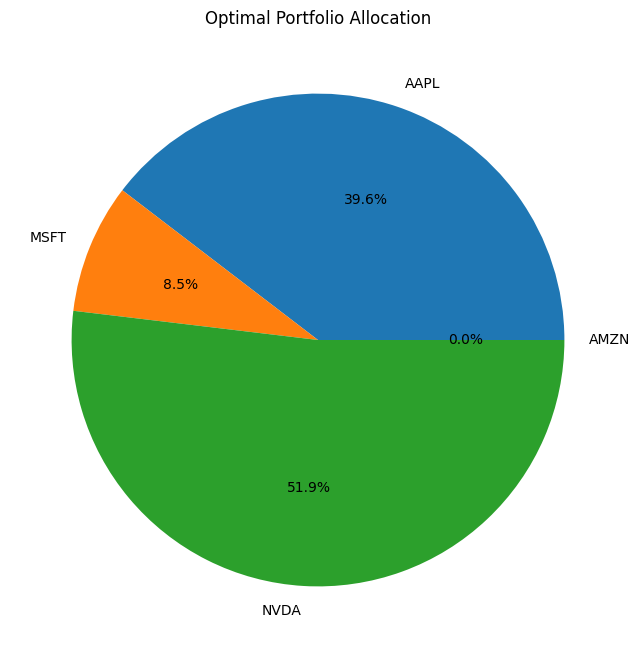

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Create a pie chart to visualize the optimal portfolio allocation
plt.pie(
    optimal_weights,
    labels=tickers,
    autopct='%1.1f%%' # Show percentage allocation
)

plt.title('Optimal Portfolio Allocation')
plt.show()